In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install numpy nltk scikit-learn gensim indic-nlp-library stopwordsiso

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 10.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# HINGLISH / HINDI LDA TOPIC NUMBER SELECTION USING C_V
# ============================================================

import json
import glob
import os
import re

import numpy as np
import nltk

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from indicnlp.tokenize import indic_tokenize
from stopwordsiso import stopwords as iso_stopwords


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42

COMMUNITY = "motivational"

TRANSCRIPT_DIR = (
    f"/content/drive/MyDrive/Transcripts_CSS/transcripts_{COMMUNITY}"
)

N_TOPICS = [5, 10, 15, 20, 25, 30, 35, 40]

TOP_N_WORDS = 10


# ============================================================
# 2. NLTK RESOURCES
# ============================================================

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")


# ============================================================
# 3. LOAD TRANSCRIPTS
# ============================================================

json_files = sorted(
    glob.glob(os.path.join(TRANSCRIPT_DIR, "*.json"))
)

docs_raw = []

for fpath in json_files:

    try:

        with open(fpath, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Combine all segment texts
        text = " ".join(
            seg.get("text", "").strip()
            for seg in data.get("segments", [])
        )

        text = text.strip()

        if text:
            docs_raw.append(text)

    except Exception as e:

        print(f"Could not read: {fpath}")
        print("Error:", e)


print(f"Loaded {len(docs_raw)} transcripts for community: {COMMUNITY}")

if len(docs_raw) == 0:
    raise ValueError("No transcripts were loaded. Check TRANSCRIPT_DIR.")


print("\nSample:")
print(docs_raw[0][:500])


# ============================================================
# 4. STOPWORDS
# ============================================================

# English stopwords
en_stops = set(
    nltk.corpus.stopwords.words("english")
)

# Hindi stopwords
hi_stops = set(
    iso_stopwords("hi")
)

# Common Hinglish conversational words
hinglish_stops = {
    "hai", "hain", "tha", "thi", "the",
    "kar", "karna", "karo", "kiya",
    "aur",
    "yeh", "ye",
    "wo", "woh",
    "ko", "ke", "ki", "ka",
    "se",
    "me", "mein",
    "pe", "par",
    "bhi",
    "toh", "to",
    "na",
    "nahi", "nhi",
    "mat",
    "bas",
    "agar",
    "jab", "tab",
    "phir", "fir",
    "abhi", "ab",
    "sirf",
    "kuch",
    "sab",
    "log",
    "aap",
    "hum",
    "main",
    "mujhe",
    "tumhe",
    "unhe",
    "iska",
    "uska",
    "apna",
    "apne",
    "wala",
    "waale",
    "raha",
    "rahi",
    "rahe",
    "okay",
    "ok",
    "like",
    "basically",
    "actually",
    "right",
    "guys",
    "yeah",
    "yaar",
    "bhai",
    "matlab",
    "mtlb",
    "lekin",
    "leke",
    "lega",
    "legi"
}

all_stops = en_stops | hi_stops | hinglish_stops


# ============================================================
# 5. TOKENIZATION
# ============================================================

def tokenize_mixed(text):

    # Indic tokenizer handles Hindi + Roman text
    raw_tokens = indic_tokenize.trivial_tokenize(text)

    cleaned = []

    for token in raw_tokens:

        token = token.lower().strip(
            ".,!?।\"'‘’“”()[]{}:;/-_"
        )

        if not token:
            continue

        # Remove stopwords
        if token in all_stops:
            continue

        # Keep:
        #   - normal alphanumeric tokens
        #   - Hindi/Devanagari tokens
        has_devanagari = any(
            "\u0900" <= c <= "\u097F"
            for c in token
        )

        if not (token.isalnum() or has_devanagari):
            continue

        # Remove one-character tokens
        if len(token) <= 1:
            continue

        cleaned.append(token)

    return cleaned


# ============================================================
# 6. TOKENIZE ALL DOCUMENTS
# ============================================================

processed_docs = [
    tokenize_mixed(doc)
    for doc in docs_raw
]

# Remove documents that became too short
processed_docs = [
    doc
    for doc in processed_docs
    if len(doc) > 5
]

print(
    f"\nDocuments after tokenization: "
    f"{len(processed_docs)}"
)


# ============================================================
# 7. CREATE SKLEARN DOCUMENT-TERM MATRIX
# ============================================================
#
# IMPORTANT:
# We use the SAME tokenized documents here.
#

text_for_vectorizer = [
    " ".join(doc)
    for doc in processed_docs
]

vectorizer = CountVectorizer(
    analyzer="word",
    lowercase=False,

    # Same frequency thresholds
    min_df=5,
    max_df=0.95,

    # Since our documents are already tokenized
    token_pattern=r"(?u)\b\w+\b"
)

X = vectorizer.fit_transform(text_for_vectorizer)

feature_names = vectorizer.get_feature_names_out()

print(
    f"\nVocabulary size from CountVectorizer: "
    f"{len(feature_names)}"
)

print(
    f"Document-term matrix shape: "
    f"{X.shape}"
)


# ============================================================
# 8. CREATE GENSIM DICTIONARY FROM THE EXACT
#    SAME SKLEARN VOCABULARY
# ============================================================

# Convert sklearn vocabulary to a set
sklearn_vocab = set(feature_names)


# Keep ONLY words that survived CountVectorizer filtering
filtered_docs = [
    [
        word
        for word in doc
        if word in sklearn_vocab
    ]
    for doc in processed_docs
]


# Remove documents that became empty
filtered_docs = [
    doc
    for doc in filtered_docs
    if len(doc) > 0
]


# Create Gensim dictionary
dictionary = Dictionary(filtered_docs)


print(
    f"Gensim dictionary size: "
    f"{len(dictionary)}"
)


# ============================================================
# 9. CRITICAL VOCABULARY CHECK
# ============================================================

# Make sure sklearn and Gensim vocabulary match

gensim_vocab = set(dictionary.token2id.keys())

missing_from_gensim = (
    sklearn_vocab - gensim_vocab
)

missing_from_sklearn = (
    gensim_vocab - sklearn_vocab
)

print(
    f"\nWords in sklearn vocabulary: "
    f"{len(sklearn_vocab)}"
)

print(
    f"Words in Gensim vocabulary: "
    f"{len(gensim_vocab)}"
)

print(
    f"Sklearn words missing from Gensim: "
    f"{len(missing_from_gensim)}"
)

print(
    f"Gensim words missing from Sklearn: "
    f"{len(missing_from_sklearn)}"
)


# ============================================================
# 10. FORCE FINAL VOCABULARY TO BE IDENTICAL
# ============================================================

# This is the important safety step.
#
# Only use words that exist in BOTH vocabularies.

common_vocab = (
    sklearn_vocab & gensim_vocab
)


print(
    f"Common vocabulary: "
    f"{len(common_vocab)}"
)


# Rebuild documents using ONLY common vocabulary

final_docs = [
    [
        word
        for word in doc
        if word in common_vocab
    ]
    for doc in processed_docs
]


# Remove empty documents
final_docs = [
    doc
    for doc in final_docs
    if len(doc) > 0
]


# Rebuild dictionary one final time
dictionary = Dictionary(final_docs)


# ============================================================
# 11. VERIFY DICTIONARY
# ============================================================

final_vocab = set(dictionary.token2id.keys())

print(
    f"\nFinal Gensim vocabulary: "
    f"{len(final_vocab)}"
)

print(
    f"Final documents: "
    f"{len(final_docs)}"
)


if len(final_vocab) == 0:
    raise ValueError(
        "Final vocabulary is empty."
    )


# ============================================================
# 12. BUILD FINAL MATRIX AGAIN
# ============================================================
#
# Rebuild X using the EXACT SAME final vocabulary.
#

vectorizer = CountVectorizer(
    analyzer="word",
    lowercase=False,
    vocabulary=sorted(final_vocab),
    token_pattern=r"(?u)\b\w+\b"
)

X = vectorizer.fit_transform(
    [" ".join(doc) for doc in final_docs]
)

feature_names = vectorizer.get_feature_names_out()


print(
    f"Final matrix shape: "
    f"{X.shape}"
)


# ============================================================
# 13. FINAL SAFETY TEST
# ============================================================

# Every sklearn feature must exist in Gensim

for word in feature_names:

    if word not in dictionary.token2id:

        raise ValueError(
            f"Vocabulary mismatch detected: "
            f"'{word}' is not in Gensim dictionary."
        )


print(
    "\n✓ Vocabulary consistency check passed."
)


# ============================================================
# 14. TRAIN LDA + CALCULATE C_V COHERENCE
# ============================================================

COHERENCE_SCORES = []

print("\n" + "=" * 60)
print("LDA TOPIC NUMBER SEARCH")
print("=" * 60)


for n_topics in N_TOPICS:

    print(
        f"\nTraining LDA with "
        f"{n_topics} topics..."
    )

    # --------------------------------------------------------
    # Train LDA
    # --------------------------------------------------------

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=SEED,
        learning_method="batch",
        max_iter=20
    )

    lda.fit(X)


    # --------------------------------------------------------
    # Extract top words
    # --------------------------------------------------------

    topics = []

    for topic in lda.components_:

        top_indices = topic.argsort()[
            -TOP_N_WORDS:
        ][::-1]

        topic_words = [
            feature_names[i]
            for i in top_indices
        ]

        # ----------------------------------------------------
        # VERY IMPORTANT:
        # Verify every topic word exists in Gensim
        # ----------------------------------------------------

        invalid_words = [
            word
            for word in topic_words
            if word not in dictionary.token2id
        ]

        if invalid_words:

            raise ValueError(
                f"Topic contains words missing "
                f"from dictionary: {invalid_words}"
            )

        topics.append(topic_words)


    # --------------------------------------------------------
    # Calculate C_V coherence
    # --------------------------------------------------------

    coherence_model = CoherenceModel(
        topics=topics,
        texts=final_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    score = coherence_model.get_coherence()

    COHERENCE_SCORES.append(score)


    print(
        f"n_topics = {n_topics:3d} "
        f"→ coherence = {score:.4f}"
    )


# ============================================================
# 15. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL COHERENCE RESULTS")
print("=" * 60)

for n_topics, score in zip(
    N_TOPICS,
    COHERENCE_SCORES
):

    print(
        f"{n_topics:3d} topics → "
        f"{score:.4f}"
    )


# ============================================================
# 16. BEST TOPIC NUMBER
# ============================================================

best_index = int(
    np.argmax(COHERENCE_SCORES)
)

best_n_topics = N_TOPICS[best_index]

best_score = COHERENCE_SCORES[best_index]


print("\n" + "=" * 60)

print(
    f"BEST TOPIC COUNT: "
    f"{best_n_topics}"
)

print(
    f"BEST C_V COHERENCE: "
    f"{best_score:.4f}"
)

print("=" * 60)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Loaded 1019 transcripts for community: motivational

Sample:
You are not perfect just the way you are. If you thought you were, you probably wouldn't be watching this video. Now, I'm not saying this to make you insecure or to feed into the unrealistic beauty standards that we have today. I am telling you this simply to give you the honest, uncomfortable truth about why you feel and look worse than you actually could. And if you clicked on this video thinking I'm going to give you tips on how to improve your facial symmetry or how to make your skin more gl

Documents after tokenization: 1005

Vocabulary size from CountVectorizer: 6268
Document-term matrix shape: (1005, 6268)
Gensim dictionary size: 5695

Words in sklearn vocabulary: 6268
Words in Gensim vocabulary: 5695
Sklearn words missing from Gensim: 573
Gensim words missing from Sklearn: 0
Common vocabulary: 5695

Final Gensim vocabulary: 5695
Final documents: 1005
Final matrix shape: (1005, 5695)

✓ Vocabulary consistency check pa

N_TOPICS: [5, 10, 15, 20, 25, 30, 35, 40]
COHERENCE_SCORES: [np.float64(0.651), np.float64(0.618), np.float64(0.6317), np.float64(0.6007), np.float64(0.5656), np.float64(0.5752), np.float64(0.5592), np.float64(0.5774)]

Best: n_topics=5 with coherence=0.6510


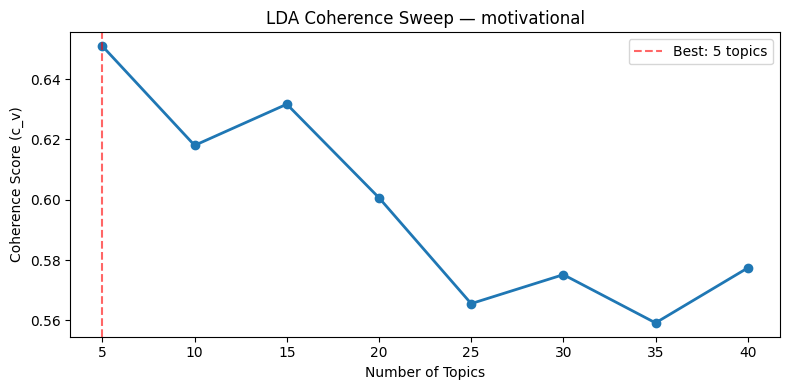

In [ ]:
import matplotlib.pyplot as plt

print("N_TOPICS:", N_TOPICS)
print("COHERENCE_SCORES:", [round(s, 4) for s in COHERENCE_SCORES])
best_idx = COHERENCE_SCORES.index(max(COHERENCE_SCORES))
print(f"\nBest: n_topics={N_TOPICS[best_idx]} with coherence={COHERENCE_SCORES[best_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(N_TOPICS, COHERENCE_SCORES, marker='o', linewidth=2)
plt.axvline(x=N_TOPICS[best_idx], color='red', linestyle='--', alpha=0.6,
            label=f'Best: {N_TOPICS[best_idx]} topics')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title(f'LDA Coherence Sweep — {COMMUNITY}')
plt.legend()
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/Transcripts_CSS/outputs/LDA_results/coherence_{COMMUNITY}.png', dpi=150)
plt.show()